In [1]:
"""
Real World Workflow

1. Data Understanding
2. EDA
3. Feature Selection
4. Scaling
5. Baseline DBSCAN
6. Cluster Assignment
7. Internal Validation
8. Hyperparameter Search
9. k-Distance Analysis
10. PCA Visualization
11. Cluster Profiling
12. Noise Analysis
13. Stability Analysis
14. Deployment Readiness
15. Interview Questions

==================================================================
"""

# ==========================================================
# STEP 0 : IMPORTS
# ==========================================================

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import (silhouette_score,davies_bouldin_score,calinski_harabasz_score)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import joblib

In [2]:
# ==========================================================
# STEP 1 : DATA UNDERSTANDING
# ==========================================================

wine = load_wine()
df = pd.DataFrame(wine.data,columns=wine.feature_names)
print(df.head())
print(df.info())
print(df.describe())
print(df.shape)

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64
0


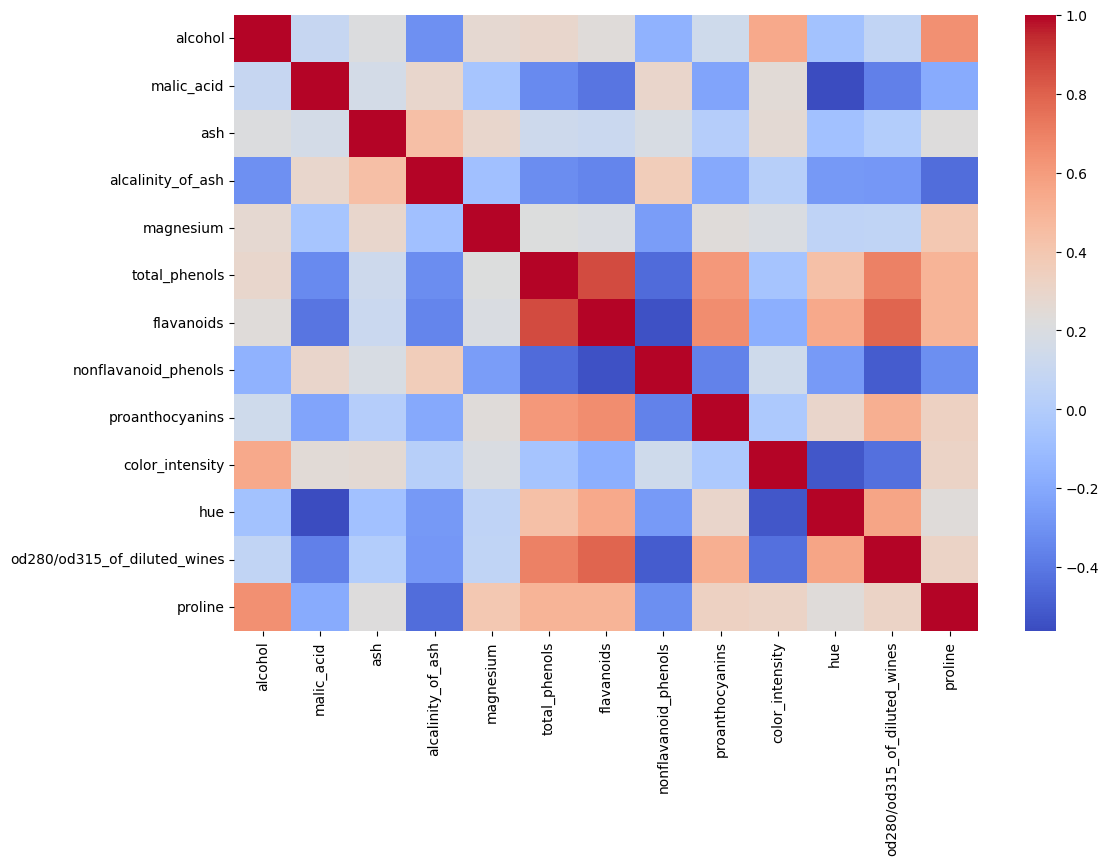

In [3]:
# ==========================================================
# STEP 2 : EDA
# ==========================================================
print(df.isnull().sum())
print(df.duplicated().sum())
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.show()

In [4]:
# ==========================================================
# STEP 3 : FEATURE SELECTION
# ==========================================================

X = df.copy()

In [5]:
# ==========================================================
# STEP 4 : SCALING
# ==========================================================

"""
DBSCAN relies on distance.
Scaling is mandatory.
"""
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# ==========================================================
# STEP 5 : BASELINE MODEL
# ==========================================================

dbscan = DBSCAN(eps=2.0,min_samples=5)

In [ ]:
# ==========================================================
# STEP 6 : CLUSTER ASSIGNMENT
# ==========================================================

labels = dbscan.fit_predict(X_scaled)
print(labels)
df["cluster"] = labels
print("\nCluster Counts")
print(df["cluster"].value_counts())


Cluster Counts
cluster
-1    85
 0    66
 4     9
 1     8
 2     5
 3     5
Name: count, dtype: int64


In [ ]:
# ==========================================================
# STEP 7 : INTERNAL VALIDATION
# ==========================================================

"""
Validation only possible if
at least 2 clusters exist.
"""
unique_clusters = set(labels)

if len(unique_clusters) > 1 and -1 in unique_clusters:
    mask = labels != -1
    sil = silhouette_score(X_scaled[mask],labels[mask])
    db = davies_bouldin_score(X_scaled[mask],labels[mask])
    ch = calinski_harabasz_score(X_scaled[mask],labels[mask])
    print("\nSilhouette:", sil)
    print("Davies Bouldin:", db)
    print("Calinski Harabasz:", ch)

In [ ]:
# ==========================================================
# STEP 8 : HYPERPARAMETER SEARCH
# ==========================================================

results = []

for eps in [0.5,1.0,1.5,2.0,2.5]:
    for min_pts in [3,5,7,10]:
        model = DBSCAN(eps=eps,min_samples=min_pts)
        lbl = model.fit_predict(X_scaled)
        clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise = np.sum(lbl == -1)
        results.append([eps,min_pts,clusters,noise])
        
tuning_df = pd.DataFrame(results,columns=["eps","min_samples","clusters", "noise_points"])

print("\nParameter Search")
print(tuning_df)

In [ ]:
# ==========================================================
# STEP 9 : K-DISTANCE GRAPH
# ==========================================================

"""
Most Important DBSCAN Step
Used to estimate eps.
"""

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:,4])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("k-Distance Graph")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()

In [ ]:
# ==========================================================
# STEP 10 : PCA VISUALIZATION
# ==========================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10,6))
scatter = plt.scatter(X_pca[:,0],X_pca[:,1],c=labels,cmap='viridis')

plt.colorbar(scatter)
plt.title("DBSCAN Clusters")
plt.show()

In [ ]:
# ==========================================================
# STEP 11 : CLUSTER PROFILING
# ==========================================================

valid_clusters = df[df["cluster"] != -1]

if len(valid_clusters):
    profile = valid_clusters.groupby("cluster").mean()
    print("\nCluster Profile")
    print(profile)

In [ ]:
# ==========================================================
# STEP 12 : NOISE ANALYSIS
# ==========================================================

noise_count = np.sum(labels == -1)
noise_percent = (noise_count/len(labels)) * 100

print("\nNoise Count:", noise_count)
print("Noise Percent:", noise_percent)
print("\nNoise Records")
print(df[df["cluster"]==-1].head())

In [ ]:
# ==========================================================
# STEP 13 : STABILITY ANALYSIS
# ==========================================================

eps_values = [1.5,2.0,2.5]

for eps in eps_values:
    model = DBSCAN(eps=eps,min_samples=5)
    lbl = model.fit_predict(X_scaled)
    clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
    print(f"eps={eps} "f"clusters={clusters}")

In [ ]:
# ==========================================================
# STEP 14 : DEPLOYMENT READINESS
# ==========================================================

"""
DBSCAN does not support predict() for new observations.

Production Options:

1. Retrain regularly
2. Use DBSCAN for
   anomaly discovery
3. Use KMeans after
   discovering structure
"""

joblib.dump(scaler,"dbscan_scaler.pkl")
print("\nScaler Saved")

# ==========================================================
# STEP 15 : INTERVIEW QUESTIONS
# ==========================================================

"""
1. What is DBSCAN?
2. Why DBSCAN was developed?
3. Difference from KMeans?
4. Difference from Hierarchical?
5. What is density?
6. What is eps?
7. What is min_samples?
8. What is a core point?
9. What is a border point?
10. What is a noise point?
11. Why DBSCAN detects outliers?
12. Why no need for K?
13. What is k-distance graph?
14. How do you choose eps?
15. Why scaling is mandatory?
16. Can DBSCAN find arbitrary shapes?
17. What happens when eps is too small?
18. What happens when eps is too large?
19. Advantages over KMeans?
20. Limitations of DBSCAN?
21. Why DBSCAN struggles with varying densities?
22. How do you validate DBSCAN?
23. Real-world use cases?
24. Can DBSCAN predict new data?
25. Explain DBSCAN end-to-end.
"""